# Phase 5 — Model Comparison and Selection
**InterveneAI · tuned LogReg / Random Forest / HistGradientBoosting vs the
Phase-4 baseline, under the frozen chronological protocol.**

`src/models/train_models.py` tuned each family on train (2017-04–2017-12) with
selection on validation (2018-01–2018-03) only; the test split (2018-04–2018-06)
was scored in one final pass. XGBoost/LightGBM are not installed here and were
deliberately not added — HistGradientBoosting covers gradient boosting via
scikit-learn. This notebook verifies every saved number by recomputation, then
compares PR/ROC, thresholds, top-k/lift and calibration. Selection is never
accuracy-driven. The reasoning section is written after execution, from results.

In [1]:
import json
import sys
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score, roc_curve)

ROOT = None
for cand in [Path("data/processed/customer_features_v3.parquet"),
             Path("../data/processed/customer_features_v3.parquet")]:
    if cand.exists():
        ROOT = cand.resolve().parents[2]
        break
assert ROOT is not None, "data file not found"
sys.path.insert(0, str(ROOT))

def find(base):
    p = ROOT / base
    assert p.exists(), p
    return p

from src.evaluation.evaluate_models import comparison_frame

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 11})
pd.options.display.float_format = "{:.6f}".format

df = pd.read_parquet(find("data/processed/customer_features_v3.parquet"))
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
with open(find("models/model_comparison.json")) as f:
    saved = json.load(f)
FEATURES = saved["features"]
TARGET = saved["target"]
TRAIN_END = pd.Timestamp(saved["splits"]["train"][1])
VAL_END = pd.Timestamp(saved["splits"]["val"][1])

pipes = {}
for name in ["logreg", "rf", "hgb"]:
    pipes[name] = joblib.load(find("models/candidates/" + name + ".pkl"))["pipeline"]
pipes["baseline_logreg"] = joblib.load(find("models/baseline_pipeline.pkl"))["pipeline"]
champ = joblib.load(find("models/champion_pipeline.pkl"))
print("candidates:", list(pipes), "| champion file family:", champ["family"])
print("params:", champ["params"])

candidates: ['logreg', 'rf', 'hgb', 'baseline_logreg'] | champion file family: logreg
params: {'C': 1.0}


## 1. Frozen splits and independent verification
Splits are rebuilt from snapshot months and checked against the saved JSON.
Then every test PR-AUC / ROC-AUC / Brier is recomputed from the saved
pipelines — any mismatch fails loudly, so the table below is verified.

In [2]:
train = df[df["snapshot_date"] <= TRAIN_END]
val = df[(df["snapshot_date"] > TRAIN_END) & (df["snapshot_date"] <= VAL_END)]
test = df[df["snapshot_date"] > VAL_END]
assert train["snapshot_date"].max() < val["snapshot_date"].min()
assert val["snapshot_date"].max() < test["snapshot_date"].min()
X_test, y_test = test[FEATURES], np.asarray(test[TARGET])
print("test rows:", len(test), "| positives:", int(y_test.sum()))

for name, pipe in pipes.items():
    s = pipe.predict_proba(X_test)[:, 1]
    exp = saved["details"][name]["test"]
    for m, fn in [("pr_auc", average_precision_score), ("roc_auc", roc_auc_score),
                  ("brier", brier_score_loss)]:
        got = float(fn(y_test, s))
        assert abs(got - exp[m]) < 1e-9, (name, m, got, exp[m])
print("all test metrics reproduced from saved pipelines — comparison is verified")

test rows: 114388 | positives: 620


all test metrics reproduced from saved pipelines — comparison is verified


## 2. Comparison table (test set, single final pass)
Primary column is test PR-AUC; accuracy appears nowhere. Val PR-AUC is shown
because that — not test — drove selection.

In [3]:
tab = comparison_frame(saved["test_comparison"])
print(tab.to_string())
print()
print("val -> test PR-AUC gaps:")
for row in saved["test_comparison"]:
    print(" ", row["model"], ":",
          str(round(row["val_pr_auc"], 4)), "->", str(round(row["test_pr_auc"], 4)))

                 val PR-AUC  test PR-AUC  test ROC-AUC  test Brier     P@5%  lift@5%  F1 (val thr)
model                                                                                             
logreg             0.020600     0.012600      0.625000    0.227870 0.018500 3.420000      0.038800
rf                 0.011200     0.011100      0.583100    0.144650 0.014300 2.650000      0.040600
hgb                0.014900     0.012100      0.593500    0.204670 0.017000 3.130000      0.047500
baseline_logreg    0.020600     0.012600      0.625000    0.227870 0.018500 3.420000      0.038800

val -> test PR-AUC gaps:
  logreg : 0.0206 -> 0.0126
  rf : 0.0112 -> 0.0111
  hgb : 0.0149 -> 0.0121
  baseline_logreg : 0.0206 -> 0.0126


## 3. Ranking curves — PR and ROC per model
Dashed grey = random ranking (prevalence for PR, diagonal for ROC).

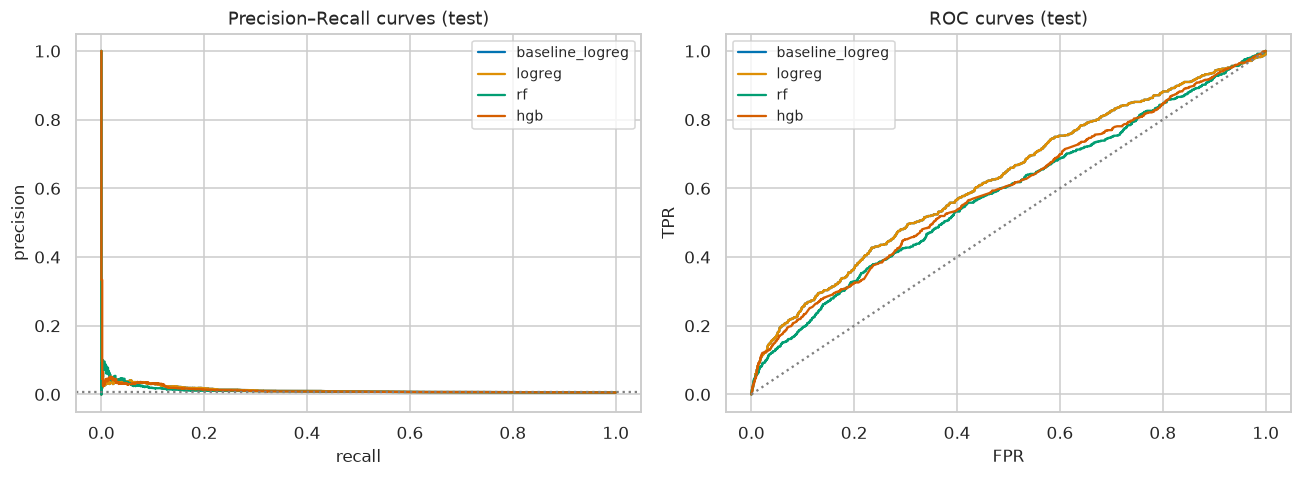

In [4]:
order = ["baseline_logreg", "logreg", "rf", "hgb"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in order:
    s = pipes[name].predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, s)
    axes[0].step(r, p, where="post", label=name)
axes[0].axhline(y_test.mean(), color="grey", linestyle=":")
axes[0].set_title("Precision–Recall curves (test)")
axes[0].set_xlabel("recall")
axes[0].set_ylabel("precision")
axes[0].legend(fontsize=9)
for name in order:
    s = pipes[name].predict_proba(X_test)[:, 1]
    f, t, _ = roc_curve(y_test, s)
    axes[1].plot(f, t, label=name)
axes[1].plot([0, 1], [0, 1], color="grey", linestyle=":")
axes[1].set_title("ROC curves (test)")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Calibration per model
Same quantile-binned protocol as Phase 4. Lower Brier is better; the diagonal
is perfect calibration. Balanced class weights buy ranking at the price of
probability quality — the curves show who paid most.

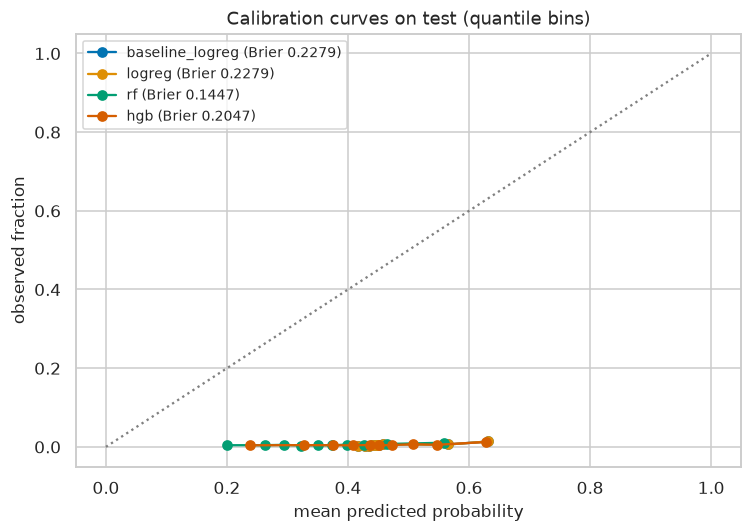

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in ["baseline_logreg", "logreg", "rf", "hgb"]:
    cal = saved["details"][name]["test_calibration"]
    ax.plot(cal["prob_pred"], cal["prob_true"], marker="o", label=name +
            " (Brier " + str(round(saved["details"][name]["test"]["brier"], 4)) + ")")
ax.plot([0, 1], [0, 1], color="grey", linestyle=":")
ax.set_title("Calibration curves on test (quantile bins)")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed fraction")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Operating view — top-k precision/lift and F1 thresholds
Thresholds were fixed on validation (F1 grid); top-k needs no threshold.
Lift is relative to test prevalence (1.0 = random targeting).

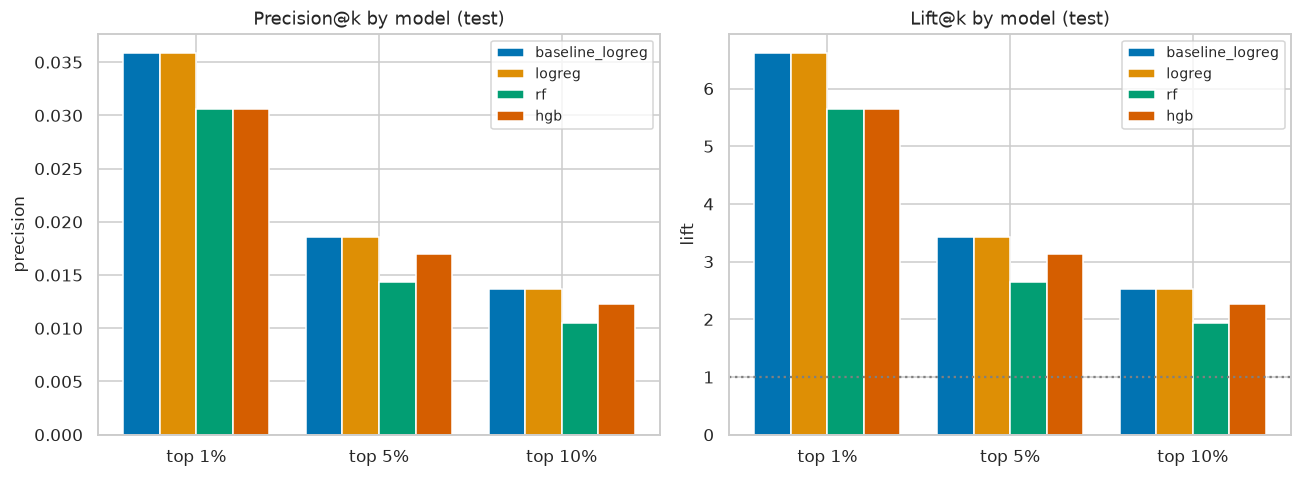

F1 thresholds from validation -> test F1:
  baseline_logreg : t = 0.87 | test P = 0.0361 R = 0.0419 F1 = 0.0388
  logreg : t = 0.87 | test P = 0.0361 R = 0.0419 F1 = 0.0388
  rf : t = 0.735 | test P = 0.0448 R = 0.0371 F1 = 0.0406
  hgb : t = 0.675 | test P = 0.03 R = 0.1129 F1 = 0.0475


In [6]:
kfracs = [r["frac"] for r in saved["details"]["logreg"]["test_top_k"]]
x = np.arange(len(kfracs))
width = 0.2
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, name in enumerate(["baseline_logreg", "logreg", "rf", "hgb"]):
    ps = [r["precision"] for r in saved["details"][name]["test_top_k"]]
    ls = [r["lift"] for r in saved["details"][name]["test_top_k"]]
    axes[0].bar(x + (i - 1.5) * width, ps, width, label=name)
    axes[1].bar(x + (i - 1.5) * width, ls, width, label=name)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["top " + str(int(100 * f)) + "%" for f in kfracs])
axes[0].set_title("Precision@k by model (test)")
axes[0].set_ylabel("precision")
axes[0].legend(fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["top " + str(int(100 * f)) + "%" for f in kfracs])
axes[1].axhline(1.0, color="grey", linestyle=":")
axes[1].set_title("Lift@k by model (test)")
axes[1].set_ylabel("lift")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print("F1 thresholds from validation -> test F1:")
for name in ["baseline_logreg", "logreg", "rf", "hgb"]:
    d = saved["details"][name]
    m = d["test_at_f1_threshold"]
    print(" ", name, ": t =", round(d["f1_threshold_from_val"], 3),
          "| test P =", round(m["precision"], 4),
          "R =", round(m["recall"], 4), "F1 =", round(m["f1"], 4))

## 6. Model-selection reasoning (from the results above — no accuracy involved)

**Selected champion: tuned Logistic Regression (C = 1.0), saved to
`models/champion_pipeline.pkl`.** Accuracy played no role — it was never
computed for any candidate.

1. **Pre-registered criterion decides.** Selection was fixed before seeing
   test: best validation PR-AUC. LogReg won validation outright (0.0206 vs
   HGB 0.0149 vs RF 0.0112), so it is the champion regardless of what test
   says. Test exists to confirm, not to shop.
2. **Test confirms the validation ordering.** Test PR-AUC ranks identically
   (LogReg 0.0126 > HGB 0.0121 > RF 0.0111) — no selection reversal. LogReg
   also leads test ROC-AUC (0.625 vs 0.594/0.583) and lift@5% (3.42x vs
   3.13x/2.65x), so secondary operating views agree rather than conflict.
3. **Tuning validated the baseline instead of replacing it.** The grid search
   returned C = 1.0 — bit-identical scores to the Phase-4 baseline on every
   metric — so the champion adds zero complexity over the reference. That is
   a result, not a failure: regularisation strength is immaterial here.
4. **Trees lose honestly.** One RF config scored val ROC-AUC 0.483 (worse
   than random); the best RF/HGB configs trail on ranking while winning
   Brier (RF 0.145, HGB 0.205 vs LogReg 0.228) and HGB wins test F1 (0.048
   vs 0.039). With 10 weak features and 943 train positives, flexible models
   fit noise; their better calibration does not outweigh worse ranking when
   ranking is the task. If calibrated probabilities become the product need,
   that trade-off should be revisited explicitly — not smuggled in via F1.
5. **Limits of this selection.** Margins are small on a single test window;
   every model decayed from val to test (LogReg 0.021 → 0.013), so the gap
   may partly be noise and temporal drift rather than a durable superiority.
   The champion is the best-supported choice under this protocol, not a claim
   that linear models are generally superior. Next phases should test
   stability across rolling windows before trusting the gap.
